Loading required package: abind

Loading required package: sf

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



[1] "list"


           Length Class  Mode     
EPSG_32632 1      -none- character

🌟 Stars: 10.661 seg | mean = 3766.625 


downsample set to 21



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,907950,48.5,1431682,76.5,1431682,76.5
Vcells,122716370,936.3,559437056,4268.2,675234456,5151.7


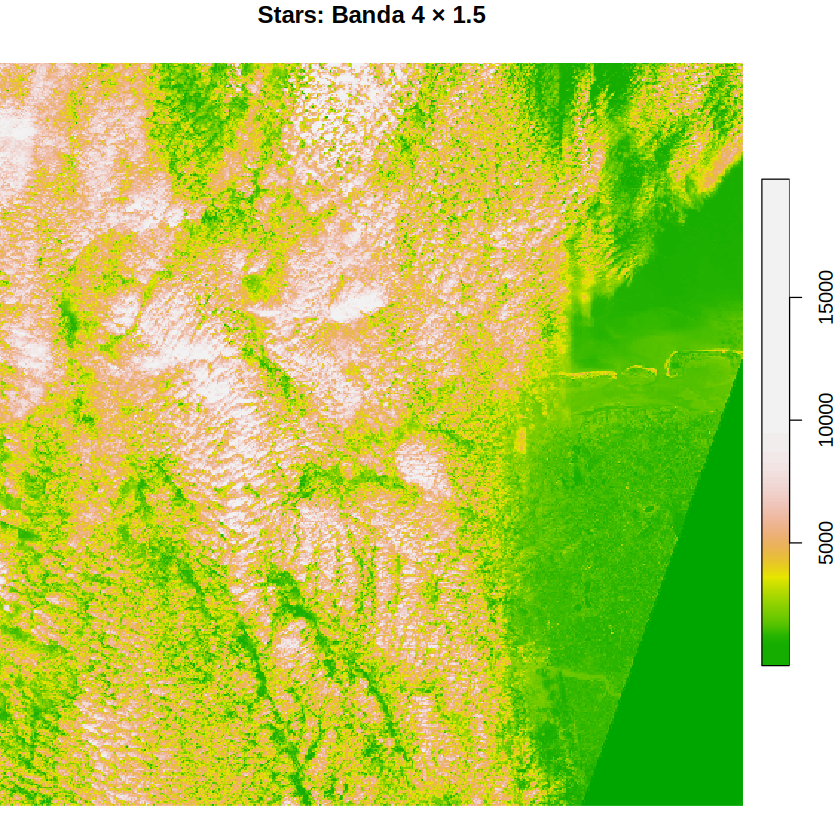

In [1]:
library(stars)

t0 <- Sys.time()

# Leer la ruta del archivo .zip en formato Virtual GDAL
s2_path <- readLines("../data/s2_shared_path.txt")

# Cargar el raster de Sentinel-2
r <- read_stars(s2_path)

# Seleccionar banda 4 (rojo) de la imagen
b4 <- r[,,,1]
print(typeof(b4))

# Verificar valores de b4
summary(b4)

res_stars <- b4 * 1.5

res_mem <- st_as_stars(res_stars)

m_stars <- mean(as.vector(res_mem[[1]]), na.rm = TRUE)

# Realizar una operación simple sobre la banda (escala, luego calcular media global)
t_stars <- as.numeric(Sys.time() - t0)

cat("🌟 Stars:",
    round(t_stars, 3), "seg |",
    "mean =", round(m_stars, 6), "\n")

# %%
# ------------------------------------------------
# 7. Plot (FUERA DEL BENCHMARK, proxy)
# ------------------------------------------------
plot(res_stars, col = terrain.colors(100),
     main = "Stars: Banda 4 × 1.5")

# %%
# ------------------------------------------------
# 8. Limpieza
# ------------------------------------------------
rm(r, b4, res_stars)
gc()
